# Weight Decay

通过限制参数值的选择范围控制模型容量

防止模型过拟合，通过在训练过程中惩罚过大的权重参数，让模型倾向于学习更简单的模式，从而提高模型在未知数据上的泛化能力

$$Loss_{total} = Loss_{original} + \frac{\lambda}{2} \sum \|w\|^2$$

$\lambda$ 越大，对权重的惩罚就越严厉

## 参数更新法则

在没有 Weight Decay 时
$$w_{t+1} = w_t - \eta \cdot \nabla Loss(w_t)$$

当存在 Weight Decay 时
$$w_{t+1} = w_t - \eta \cdot (\nabla Loss(w_t) + \lambda w_t)$$
$$w_{t+1} = (1 - \eta\lambda) w_t - \eta \cdot \nabla Loss(w_t)$$
这里发生了两个动作
1. 权重衰减：$(1 - \eta\lambda) w_t$
2. 梯度下降：$- \eta \cdot \nabla Loss(w_t)$

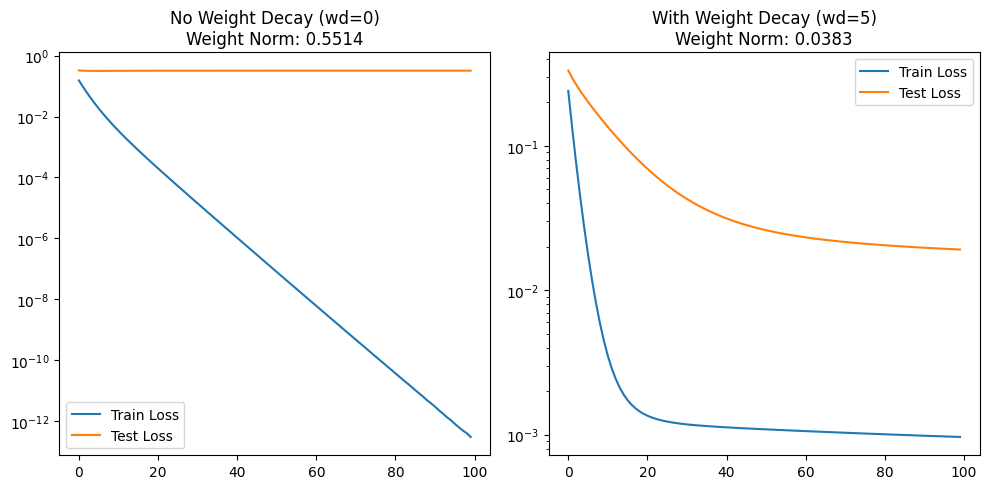

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. 构造数据集
n_train, n_test, n_features = 20, 100, 200
true_w, true_b = torch.ones((n_features, 1)) * 0.01, 0.05

# 生成随机数据并加上一点噪声
X = torch.randn((n_train + n_test, n_features))
y = torch.matmul(X, true_w) + true_b
y += torch.normal(0, 0.01, y.shape)

train_X, train_y = X[:n_train], y[:n_train]
test_X, test_y = X[n_train:], y[n_train:]

# 2. 定义训练逻辑
def train(weight_decay):
    # 定义简单的线性模型
    model = nn.Linear(n_features, 1)
    # 使用 MSE 损失函数
    criterion = nn.MSELoss()
    
    # 核心：在优化器中设置 weight_decay 参数
    # 我们只对 weight 做衰减，不对 bias 做衰减
    optimizer = torch.optim.SGD([
        {"params": model.weight, "weight_decay": weight_decay},
        {"params": model.bias, "weight_decay": 0} 
    ], lr=0.01)

    train_ls, test_ls = [], []
    
    for epoch in range(100):
        optimizer.zero_grad()
        output = model(train_X)
        loss = criterion(output, train_y)
        loss.backward()
        optimizer.step()
        
        # 记录每个 epoch 的损失
        with torch.no_grad():
            train_ls.append(criterion(model(train_X), train_y).item())
            test_ls.append(criterion(model(test_X), test_y).item())
            
    return train_ls, test_ls, model.weight.norm().item()

# 3. 运行对比实验
# 实验 A: 无权重衰减 (wd=0)
train_loss0, test_loss0, norm0 = train(weight_decay=0)
# 实验 B: 有权重衰减 (wd=5)
train_loss5, test_loss5, norm5 = train(weight_decay=5)

# 4. 可视化结果
plt.figure(figsize=(10, 5))

# 绘制 wd=0 的情况
plt.subplot(1, 2, 1)
plt.semilogy(train_loss0, label='Train Loss')
plt.semilogy(test_loss0, label='Test Loss')
plt.title(f'No Weight Decay (wd=0)\nWeight Norm: {norm0:.4f}')
plt.legend()

# 绘制 wd=5 的情况
plt.subplot(1, 2, 2)
plt.semilogy(train_loss5, label='Train Loss')
plt.semilogy(test_loss5, label='Test Loss')
plt.title(f'With Weight Decay (wd=5)\nWeight Norm: {norm5:.4f}')
plt.legend()

plt.tight_layout()
plt.show()